<a href="https://colab.research.google.com/github/AyushFegade/ayushfegade/blob/main/ayushfegade.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display plots
%matplotlib inline
sns.set_style("whitegrid")

In [25]:
df = pd.read_csv("penguins_size.csv")

# Display first 5 rows
df.head()

,species,island,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,MALE
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,FEMALE
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,FEMALE
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,FEMALE


In [26]:
# Shape of dataset
print("Shape:", df.shape)

# Column names
print("\nColumns:")
print(df.columns)

# Data types
print("\nData Types:")
print(df.dtypes)

# Dataset information
print("\nDataset Info:")
df.info()

Shape: (344, 7)

Columns:
Index(['species', 'island', 'culmen_length_mm', 'culmen_depth_mm',
       'flipper_length_mm', 'body_mass_g', 'sex'],
      dtype='object')

Data Types:
species               object
island                object
culmen_length_mm     float64
culmen_depth_mm      float64
flipper_length_mm    float64
body_mass_g          float64
sex                   object
dtype: object

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    object 
 1   island             343 non-null    object 
 2   culmen_length_mm   342 non-null    float64
 3   culmen_depth_mm    342 non-null    float64
 4   flipper_length_mm  341 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                334 non-null    object 
dtypes: float64(4), object(3)
memory usage: 18.9+ KB


In [27]:
# Statistical summary
df.describe()

,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g
count,342.000000,342.000000,341.000000,342.000000
mean,43.921930,17.151170,200.873900,4201.754386
std,5.459584,1.974793,14.061585,801.954536
min,32.100000,13.100000,172.000000,2700.000000
25%,39.225000,15.600000,190.000000,3550.000000
50%,44.450000,17.300000,197.000000,4050.000000
75%,48.500000,18.700000,213.000000,4750.000000
max,59.600000,21.500000,231.000000,6300.000000


In [28]:
# For categorical columns
df.describe(include='object')

,species,island,sex
count,344,343,334
unique,4,3,3
top,Adelie,Biscoe,MALE
freq,151,167,168


In [29]:
# Value counts
print(df['species'].value_counts())

print(df['island'].value_counts())

print(df['sex'].value_counts())

species
Adelie       151
Gentoo       123
Chinstrap     67
?              3
Name: count, dtype: int64
island
Biscoe       167
Dream        124
Torgersen     52
Name: count, dtype: int64
sex
MALE      168
FEMALE    165
.           1
Name: count, dtype: int64


In [30]:
# Missing values
df.isnull().sum()

,0
species,0
island,1
culmen_length_mm,2
culmen_depth_mm,2
flipper_length_mm,3
body_mass_g,2
sex,10


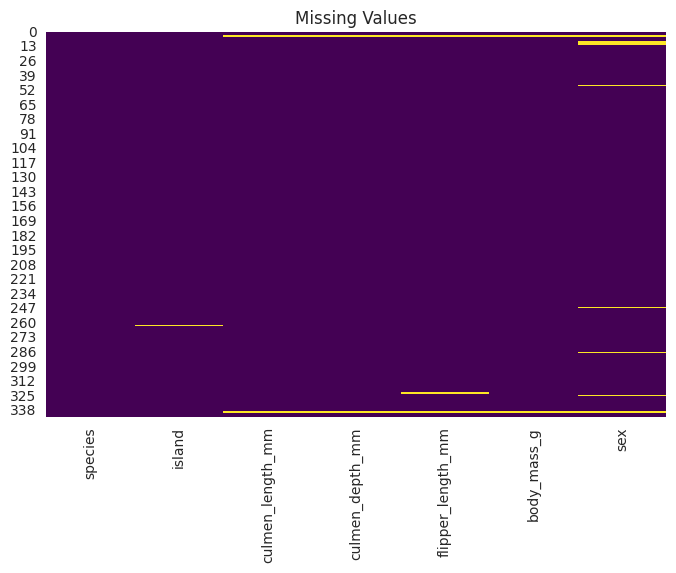

In [31]:
plt.figure(figsize=(8,5))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title("Missing Values")
plt.show()

In [32]:
# Data Cleaning
print("Duplicate Rows:", df.duplicated().sum())

df.drop_duplicates(inplace=True)

print("Shape after removing duplicates:", df.shape)

Duplicate Rows: 0
Shape after removing duplicates: (344, 7)


In [33]:
# Handling Missing Values
# Fill numerical columns
num_cols = df.select_dtypes(include=np.number).columns

for col in num_cols:
    df[col].fillna(df[col].mean(), inplace=True)

# Fill categorical columns
cat_cols = df.select_dtypes(include='object').columns

for col in cat_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

# Check again
df.isnull().sum()

/tmp/ipykernel_2700/2708834900.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mean(), inplace=True)
/tmp/ipykernel_2700/2708834900.py:12: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try usi

,0
species,0
island,0
culmen_length_mm,0
culmen_depth_mm,0
flipper_length_mm,0
body_mass_g,0
sex,0


In [34]:
# Data Transformation
# Binning
df['Mass_Category'] = pd.cut(
    df['body_mass_g'],
    bins=3,
    labels=['Low','Medium','High']
)

df[['body_mass_g','Mass_Category']].head()

,body_mass_g,Mass_Category
0,3750.000000,Low
1,3800.000000,Low
2,3250.000000,Low
3,4201.754386,Medium
4,3450.000000,Low


In [35]:
# Encoding
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df['species_encoded'] = le.fit_transform(df['species'])

df[['species','species_encoded']].head()

,species,species_encoded
0,Adelie,1
1,Adelie,1
2,Adelie,1
3,Adelie,1
4,Adelie,1


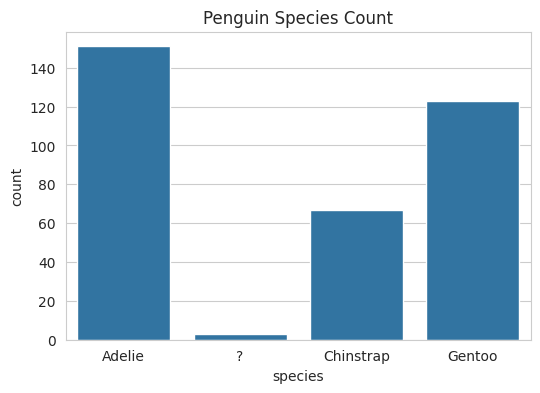

In [36]:
# Univariate Analysis
# 1. Count Plot
plt.figure(figsize=(6,4))
sns.countplot(x='species', data=df)
plt.title("Penguin Species Count")
plt.show()

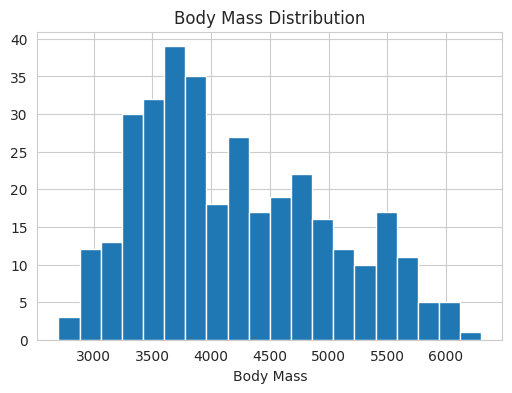

In [37]:
# 2. Histogram
plt.figure(figsize=(6,4))
plt.hist(df['body_mass_g'], bins=20)
plt.title("Body Mass Distribution")
plt.xlabel("Body Mass")
plt.show()

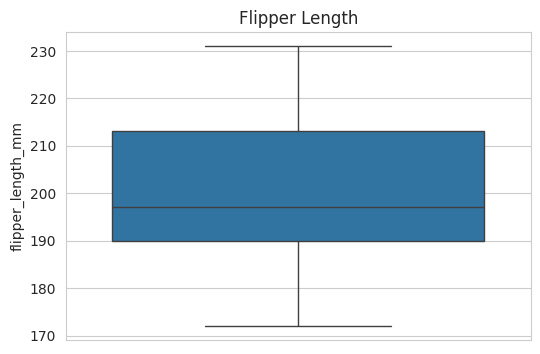

In [38]:
# 3. Box Plot
plt.figure(figsize=(6,4))
sns.boxplot(y=df['flipper_length_mm'])
plt.title("Flipper Length")
plt.show()

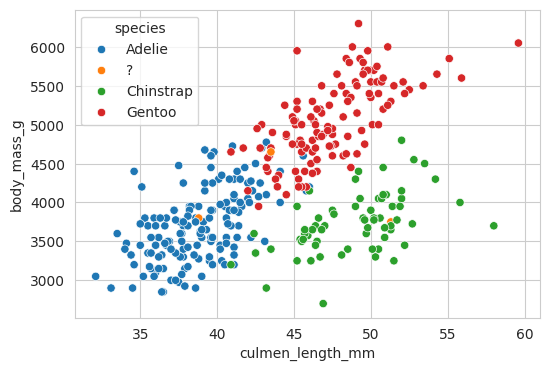

In [39]:
# Bivariate Analysis
# 1. Scatter Plot
plt.figure(figsize=(6,4))
sns.scatterplot(
    x='culmen_length_mm',
    y='body_mass_g',
    hue='species',
    data=df
)
plt.show()

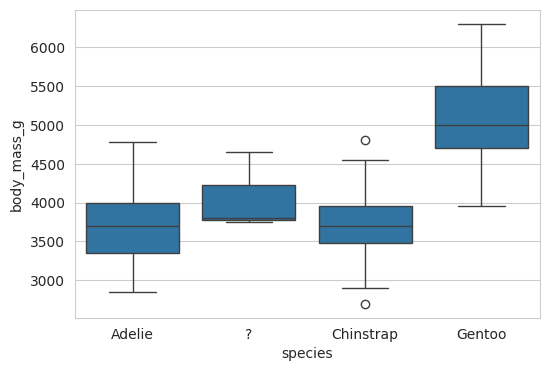

In [40]:
# 2. Box Plot
plt.figure(figsize=(6,4))
sns.boxplot(
    x='species',
    y='body_mass_g',
    data=df
)
plt.show()

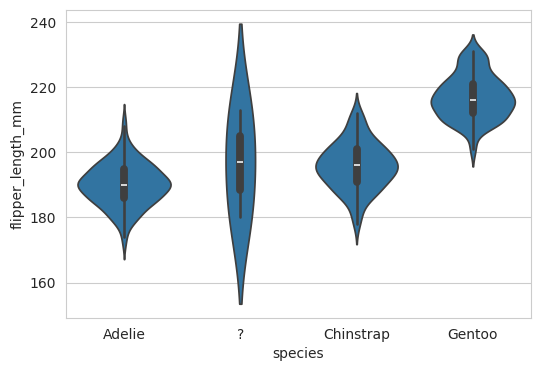

In [41]:
# 3. Violin Plot
plt.figure(figsize=(6,4))
sns.violinplot(
    x='species',
    y='flipper_length_mm',
    data=df
)
plt.show()

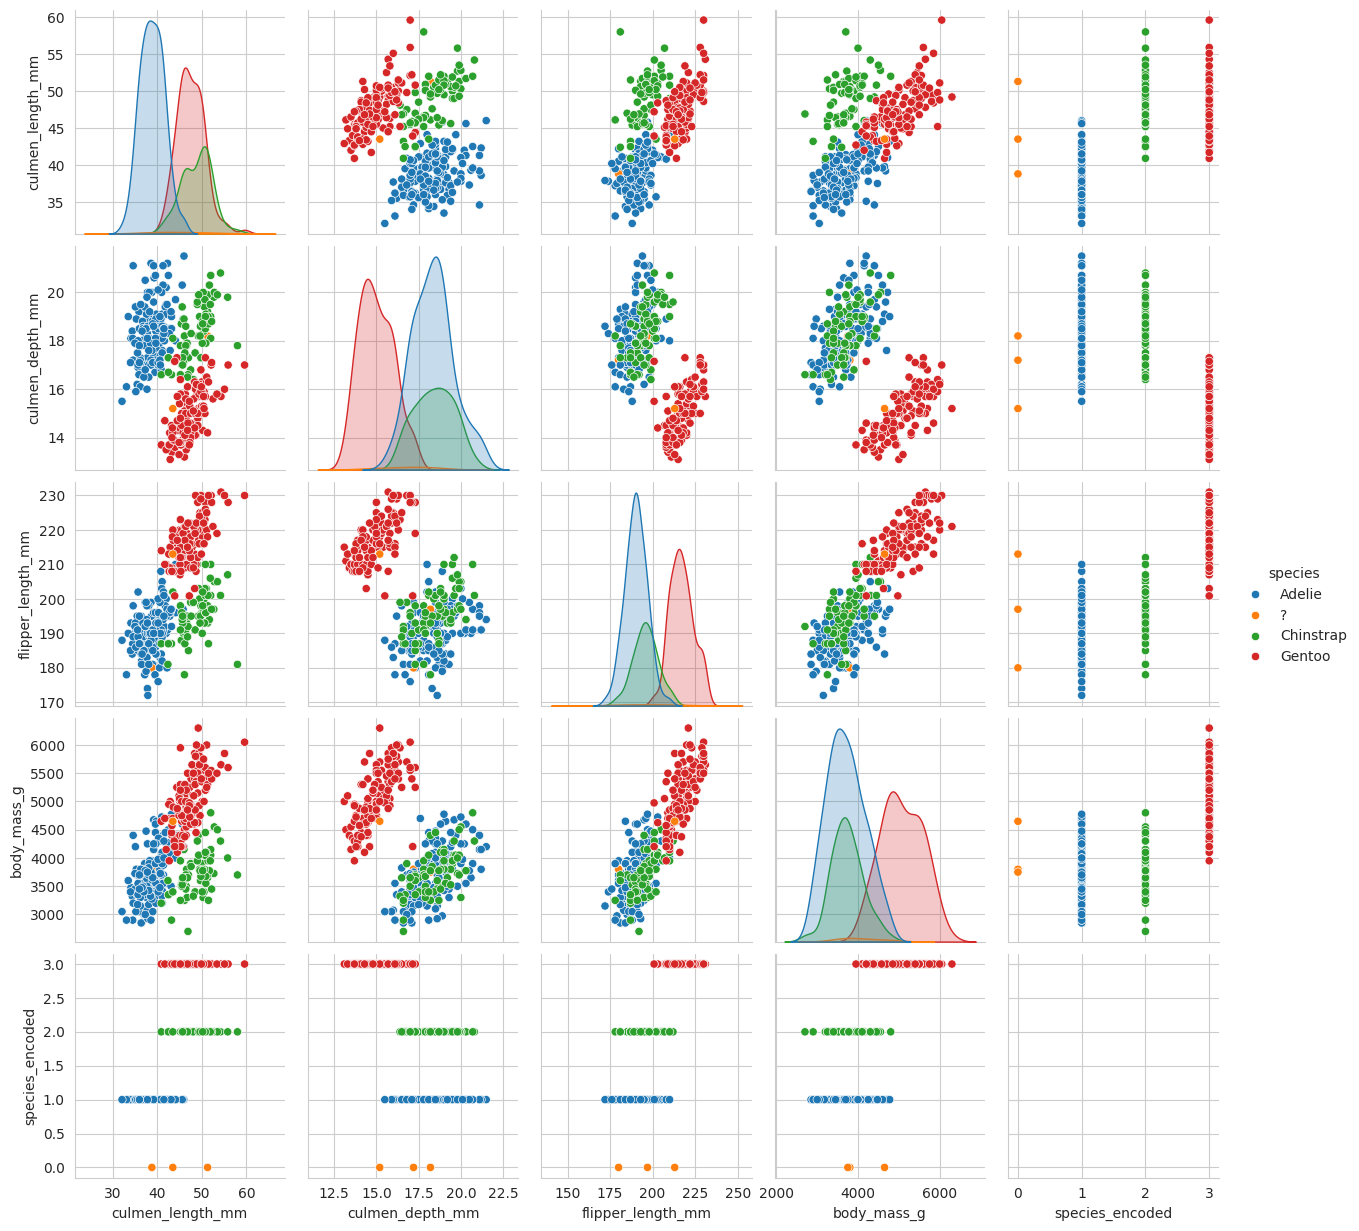

In [42]:
# Multivariate Analysis
# 1. Pair Plot
sns.pairplot(df, hue='species')
plt.show()

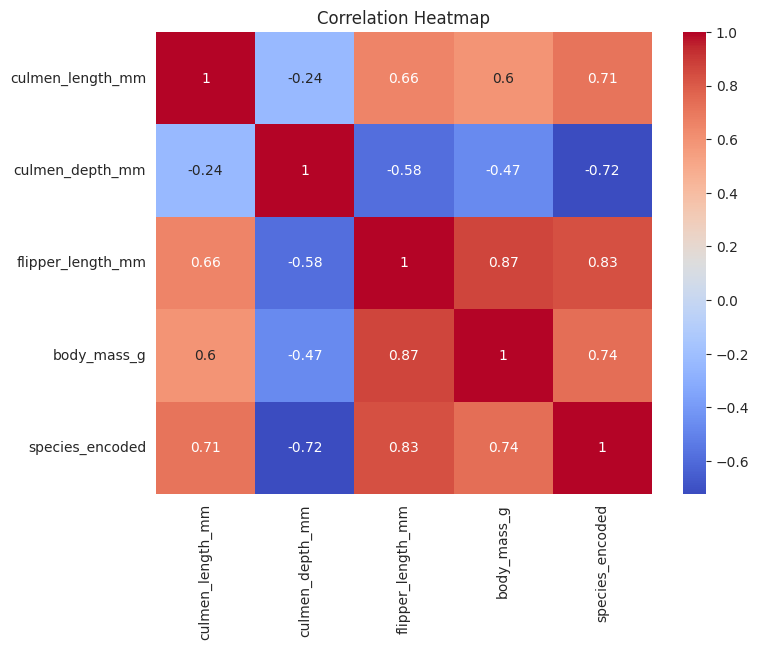

In [43]:
# 2. Heatmap
plt.figure(figsize=(8,6))

corr = df.select_dtypes(include=np.number).corr()

sns.heatmap(corr, annot=True, cmap='coolwarm')

plt.title("Correlation Heatmap")
plt.show()

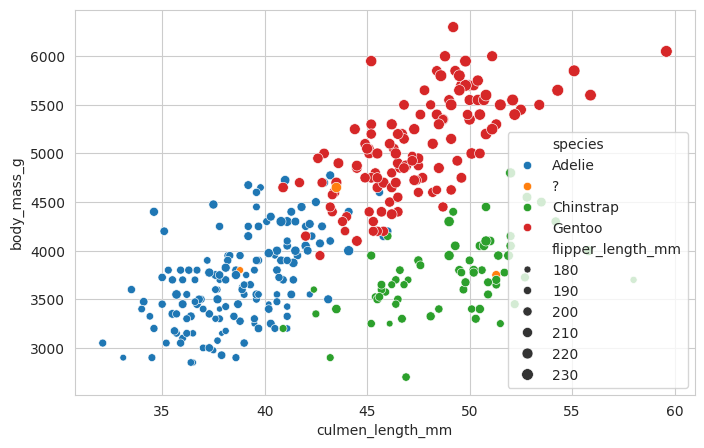

In [44]:
# 3. Scatter Plot with Multiple Variables
plt.figure(figsize=(8,5))

sns.scatterplot(
    x='culmen_length_mm',
    y='body_mass_g',
    hue='species',
    size='flipper_length_mm',
    data=df
)

plt.show()